In [2]:
# %pip install torch

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [3]:
# %pip install pandas numpy  

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE, global_mean_pool

In [5]:
THREAT_PATH = r"E:\insider detection system threat\insider_4_2_final.csv"
# THREAT_PATH ="E:\insider detection system threat\insider_4_2_final.csv"
threats = pd.read_csv(THREAT_PATH)
threats["user"]  = threats["user"].str.strip()
threats["start"] = pd.to_datetime(threats["start"])
threats["end"]   = pd.to_datetime(threats["end"])

# Normalise type label: 1=Exfil, 2=Sabotage
threats["threat_type"] = threats["what type of threat"].str.strip().str.lower()
threats["type_id"] = threats["threat_type"].map(
    lambda x: 1 if "exfil" in x else 2
)
print(threats[["user","start","end","type_id"]].head())
print("end")

      user               start                 end  type_id
0  AAM0658 2010-10-23 01:34:19 2010-10-29 05:23:28        1
1  AJR0932 2010-09-10 19:12:01 2010-09-18 02:02:51        1
2  BDV0168 2010-07-30 19:56:44 2010-08-10 05:16:41        1
3  BIH0745 2010-07-13 20:15:23 2010-07-13 21:20:44        1
4  BLS0678 2010-09-21 01:16:22 2010-09-30 04:48:19        1
end


In [6]:
def load_csv(name):
    df = pd.read_csv(f"{BASE}/{name}.csv")
    df.columns = df.columns.str.lower()
    df["user"] = df["user"].str.strip()
    df["date"] = pd.to_datetime(df["date"])
    return df


# BASE = "E:\insider detection system threat\r4.2"
BASE = r"E:\insider detection system threat\r4.2"

logon  = load_csv("logon")
print("over ......")
file   = load_csv("file")
print("over ......")
email  = load_csv("email")
print("over ......")


over ......
over ......
over ......


In [7]:
def basic_analysis(df, name):
    print(f"\n{name.upper()} DATASET")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isnull().sum())

In [8]:
devices = load_csv("device")

In [9]:
http   = load_csv("http")
print("over ......")

over ......


In [10]:
threats.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   details              70 non-null     str           
 1   user                 70 non-null     str           
 2   start                70 non-null     datetime64[us]
 3   end                  70 non-null     datetime64[us]
 4   label                70 non-null     int64         
 5   what type of threat  70 non-null     str           
 6   threat_type          70 non-null     str           
 7   type_id              70 non-null     int64         
dtypes: datetime64[us](2), int64(2), str(4)
memory usage: 4.5 KB


In [11]:
# %pip install glob

In [12]:
import glob
def load_ldap(path):
    df = pd.read_csv(path)

    # standardize column names
    df.columns = df.columns.str.lower()

    # clean user column
    df["user_id"] = df["user_id"].str.strip()

    # convert date column if exists
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

    return df


# ── Load all LDAP monthly files ────────────────────────────────────
ldap_files = sorted(glob.glob(f"{BASE}/LDAP/*.csv"))

ldap_all = pd.concat(
    [load_ldap(f) for f in ldap_files],
    ignore_index=True
)

# keep latest record for each user (captures role/department updates)
ldap_user = ldap_all.groupby("user_id").last().reset_index()

print("LDAP shape:", ldap_user.shape)
print("LDAP columns:", ldap_user.columns.tolist())


LDAP shape: (1000, 9)
LDAP columns: ['user_id', 'employee_name', 'email', 'role', 'business_unit', 'functional_unit', 'department', 'team', 'supervisor']


In [13]:
ldap_user.head()

,user_id,employee_name,email,role,business_unit,functional_unit,department,team,supervisor
0,AAE0190,August Armando Evans,August.Armando.Evans@dtaa.com,Manager,1,6 - PurchasingAndContracts,1 - Purchasing,NaN,Kirby Bo Pollard
1,AAF0535,Athena Amelia Foreman,Athena.Amelia.Foreman@dtaa.com,Technician,1,5 - SalesAndMarketing,3 - FieldService,2 - RegionalFieldService,Burke Randall Burnett
2,AAF0791,Aladdin Abraham Foley,Aladdin.Abraham.Foley@dtaa.com,Physicist,1,2 - ResearchAndEngineering,1 - Research,5 - Lab,Sasha Britanney Quinn
3,AAL0706,April Alika Levy,April.Alika.Levy@dtaa.com,ProductionLineWorker,1,3 - Manufacturing,3 - Assembly,4 - AssemblyDept,Alan Benjamin Holder
4,AAM0658,Abel Adam Morton,Abel.Adam.Morton@dtaa.com,Technician,1,5 - SalesAndMarketing,3 - FieldService,3 - RegionalFieldService,Hedwig Regina Livingston


In [14]:
def basic_analysis(df, name):
    print(f"\n{'='*40}")
    print(f"{name.upper()} DATASET")
    print(f"{'='*40}")
    print("Shape:", df.shape)
    print("\nColumns:")
    for col in df.columns:
        print(f" - {col} ({df[col].dtype})")
    print("\nMissing values:")
    display(df.isnull().sum().to_frame("missing_count"))
for d, n in zip([logon, file, email, http, devices],
        ["logon", "file", "email", "http", "device"]):
    basic_analysis(d, n)


LOGON DATASET
Shape: (854859, 5)

Columns:
 - id (str)
 - date (datetime64[us])
 - user (str)
 - pc (str)
 - activity (str)

Missing values:


,missing_count
id,0
date,0
user,0
pc,0
activity,0



FILE DATASET
Shape: (445581, 6)

Columns:
 - id (str)
 - date (datetime64[us])
 - user (str)
 - pc (str)
 - filename (str)
 - content (str)

Missing values:


,missing_count
id,0
date,0
user,0
pc,0
filename,0
content,0



EMAIL DATASET
Shape: (2629979, 11)

Columns:
 - id (str)
 - date (datetime64[us])
 - user (str)
 - pc (str)
 - to (str)
 - cc (str)
 - bcc (str)
 - from (str)
 - size (int64)
 - attachments (int64)
 - content (str)

Missing values:


,missing_count
id,0
date,0
user,0
pc,0
to,0
cc,1617054
bcc,2212977
from,0
size,0
attachments,0



HTTP DATASET
Shape: (28434423, 6)

Columns:
 - id (str)
 - date (datetime64[us])
 - user (str)
 - pc (str)
 - url (str)
 - content (str)

Missing values:


,missing_count
id,0
date,0
user,0
pc,0
url,0
content,0



DEVICE DATASET
Shape: (405380, 5)

Columns:
 - id (str)
 - date (datetime64[us])
 - user (str)
 - pc (str)
 - activity (str)

Missing values:


,missing_count
id,0
date,0
user,0
pc,0
activity,0


In [15]:
email["cc"]  = email["cc"].fillna("")
email["bcc"] = email["bcc"].fillna("")


In [16]:
basic_analysis(email,"email")



EMAIL DATASET
Shape: (2629979, 11)

Columns:
 - id (str)
 - date (datetime64[us])
 - user (str)
 - pc (str)
 - to (str)
 - cc (str)
 - bcc (str)
 - from (str)
 - size (int64)
 - attachments (int64)
 - content (str)

Missing values:


,missing_count
id,0
date,0
user,0
pc,0
to,0
cc,0
bcc,0
from,0
size,0
attachments,0


In [17]:
from sklearn.preprocessing import LabelEncoder
print("LDAP Feature Engineering")
ldap_enc = ldap_user[['user_id']].copy()

categorical_cols = ['role','dept','team','ITAdmin']

for col in categorical_cols:
    if col in ldap_user.columns:
        le = LabelEncoder()
        ldap_enc[f'ldap_{col}'] = le.fit_transform(
            ldap_user[col].fillna('Unknown')
        )
    else:
        ldap_enc[f'ldap_{col}'] = 0


# ITAdmin flag
if 'role' in ldap_user.columns:
    ldap_enc['is_ITAdmin'] = ldap_user['role'].str.contains(
        'itadmin', case=False, na=False
    ).astype(np.int8)
else:
    ldap_enc['is_ITAdmin'] = 0


# supervisor feature
if 'supervisor' in ldap_user.columns:

    sup_counts = (
        ldap_user.groupby('supervisor')
        .size()
        .rename('n_reports')
        .reset_index()
    )

    sup_counts.columns = ['user_id','n_reports']

    ldap_enc = ldap_enc.merge(
        sup_counts,
        on='user_id',
        how='left'
    )

    ldap_enc['n_reports'] = ldap_enc['n_reports'].fillna(0)

else:
    ldap_enc['n_reports'] = 0


LDAP_COLS = [c for c in ldap_enc.columns if c!='user_id']

print("LDAP columns:", LDAP_COLS)

print(ldap_enc.head())
LDAP_COLS = [c for c in ldap_enc.columns if c != 'user_id']
print('LDAP feature cols:', LDAP_COLS)


LDAP Feature Engineering
LDAP columns: ['ldap_role', 'ldap_dept', 'ldap_team', 'ldap_ITAdmin', 'is_ITAdmin', 'n_reports']
   user_id  ldap_role  ldap_dept  ldap_team  ldap_ITAdmin  is_ITAdmin  \
0  AAE0190         22          0         38             0           0   
1  AAF0535         39          0         11             0           0   
2  AAF0791         28          0         28             0           0   
3  AAL0706         30          0         21             0           0   
4  AAM0658         39          0         18             0           0   

   n_reports  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
LDAP feature cols: ['ldap_role', 'ldap_dept', 'ldap_team', 'ldap_ITAdmin', 'is_ITAdmin', 'n_reports']


In [18]:
WINDOW_HOURS = 12

def create_windows(df):
    df = df.copy()
    df["window"] = df["date"].dt.floor(f"{WINDOW_HOURS}h")
    return df

logon  = create_windows(logon)
devices = create_windows(devices)
http   = create_windows(http)
email  = create_windows(email)
file   = create_windows(file)

print("Log groups ready")

Log groups ready


In [19]:
logon.head()


,id,date,user,pc,activity,window
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon,2010-01-02
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon,2010-01-02
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon,2010-01-02
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon,2010-01-02
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon,2010-01-02


In [20]:
file.head()


,id,date,user,pc,filename,content,window
0,{L9G8-J9QE34VM-2834VDPB},2010-01-02 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...,2010-01-02
1,{H0W6-L4FG38XG-9897XTEN},2010-01-02 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...,2010-01-02
2,{M3Z0-O2KK89OX-5716MBIM},2010-01-02 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...,2010-01-02
3,{E1I4-S4QS61TG-3652YHKR},2010-01-02 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...,2010-01-02
4,{D4R7-E7JL45UX-0067XALT},2010-01-02 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8,2010-01-02


In [21]:
base = pd.concat([
    logon[['user','window']],
    devices[['user','window']],
    http[['user','window']],
    email[['user','window']],
    file[['user','window']]
], ignore_index=True).drop_duplicates()

base.head()

,user,window
0,NGF0157,2010-01-02
1,LRR0148,2010-01-02
3,IRM0931,2010-01-02
4,MOH0273,2010-01-02
5,LAP0338,2010-01-02


In [22]:
# 1. Pre-calculate boolean flags (Faster than doing it inside the groupby)
devices["is_connect"] = devices["activity"].eq("connect")
devices["is_disconnect"] = devices["activity"].eq("disconnect")
devices["is_after_hours"] = ((devices["date"].dt.hour < 9) | (devices["date"].dt.hour >= 17)).astype(int)

# 2. Single Groupby Aggregation
devices_features = devices.groupby(["user", "window"]).agg(
    devices_count=('activity', 'size'),
    devices_connect=('is_connect', 'sum'),
    devices_disconnect=('is_disconnect', 'sum'),
    devices_ah=('is_after_hours', 'sum')
)

# 3. Calculate missing disconnects via vectorized subtraction on the resulting columns
devices_features["devices_miss_dc"] = (
    devices_features["devices_connect"] - devices_features["devices_disconnect"]).clip(lower=0)

In [23]:
http_features = http.copy()

# create small flags first
http_features["is_ah"] = (
    (http_features["date"].dt.hour < 9) |
    (http_features["date"].dt.hour >= 17)
).astype("uint8")

http_features["is_we"] = (
    http_features["date"].dt.dayofweek >= 5
).astype("uint8")

http_features["is_we_ah"] = (
    http_features["is_ah"] & http_features["is_we"]
).astype("uint8")

# extract domain without exploding memory
http_features["domain"] = http_features["url"].str.extract(
    r"https?://([^/]+)"
)


In [24]:
SUSP_KEYWORDS = {
    'leak', 'wikileaks', 'whistleblower', 'anonymous', 'darkweb', 'tor',
    'upload', 'dropbox', 'pastebin', 'mega', 'job', 'linkedin', 'resume',
    'career', 'glassdoor', 'competitor','ambitionbox','indeed','naukari','ats'
}


In [25]:
import numpy as np
import pandas as pd

# 1. Process Keywords (Your O(1) logic is great)
keywords = set(k.lower() for k in SUSP_KEYWORDS)

def count_keywords(text):
    if not isinstance(text, str):
        return 0
    words = set(text.lower().split())
    return 1 if not words.isdisjoint(keywords) else 0

# 2. Attach the flag directly to http_features
# Using list comprehension for speed as you suggested
http_features["is_susp"] = np.array(
    [count_keywords(x) for x in http["content"]], 
    dtype='uint8'
)

# 3. Perform a SINGLE aggregation
# This is much more memory efficient than grouping twice
http_features_agg = http_features.groupby(["user", "window"]).agg(
    http_count=("url", "size"),
    http_ah=("is_ah", "sum"),
    http_we=("is_we", "sum"),
    http_we_ah=("is_we_ah", "sum"),
    http_susp_count=("is_susp", "sum"),      # Now this works!
    http_distinct_domains=("domain", "nunique") 
).reset_index()

print(http_features_agg.head())

      user              window  http_count  http_ah  http_we  http_we_ah  \
0  AAE0190 2010-01-04 00:00:00          62        9        0           0   
1  AAE0190 2010-01-04 12:00:00          81       22        0           0   
2  AAE0190 2010-01-05 00:00:00          57       17        0           0   
3  AAE0190 2010-01-05 12:00:00          86       21        0           0   
4  AAE0190 2010-01-06 00:00:00          69       25        0           0   

   http_susp_count  http_distinct_domains  
0                2                     34  
1                3                     40  
2                1                     33  
3                1                     37  
4                1                     27  


In [26]:
# http_susp_agg

In [27]:
# http_features_agg = http_features.groupby(["user", "window"]).agg(
#     http_count=("url", "size"),
#     http_ah=("is_ah", "sum"),
#     http_we=("is_we", "sum"),
#     http_we_ah=("is_we_ah", "sum"),
#     http_susp_count=("is_susp", "sum"),      # Now this works!
#     http_distinct_domains=("domain", "nunique") 
# ).reset_index()

# print(http_features_agg.head())

In [28]:
logon["is_after_hours"] = (
    (logon["date"].dt.hour < 9) | (logon["date"].dt.hour >= 17)
).astype("uint8")  # ✅ uint8 saves memory vs int64

logon["is_weekend"] = (logon["date"].dt.dayofweek >= 5).astype("uint8")
logon["hour"] = logon["date"].dt.hour.astype("uint8")

# Shared PC flag
pc_users = logon.groupby("pc")["user"].nunique()
shared_pcs = set(pc_users[pc_users > 1].index)
logon["shared_pc"] = logon["pc"].isin(shared_pcs).astype("uint8")

logon_features = logon.groupby(["user", "window"]).agg(
    logon_count    = ("date",          "size"),
    logon_ah       = ("is_after_hours","sum"),
    logon_we       = ("is_weekend",    "sum"),
    unique_pcs     = ("pc",            "nunique"),
    mean_logon_hour= ("hour",          "mean"),
    shared_pc_logon= ("shared_pc",     "sum"),  # ✅ FIX: was computed but never used
).reset_index()

print(logon_features.head())

      user              window  logon_count  logon_ah  logon_we  unique_pcs  \
0  AAE0190 2010-01-04 00:00:00            1         1         0           1   
1  AAE0190 2010-01-04 12:00:00            1         1         0           1   
2  AAE0190 2010-01-05 00:00:00            1         1         0           1   
3  AAE0190 2010-01-05 12:00:00            1         1         0           1   
4  AAE0190 2010-01-06 00:00:00            1         1         0           1   

   mean_logon_hour  shared_pc_logon  
0              8.0                1  
1             18.0                1  
2              8.0                1  
3             18.0                1  
4              8.0                1  


In [29]:
import numpy as np
import pandas as pd
import gc

# references only (no copies)
to_col = email["to"]
cc_col = email["cc"]
bcc_col = email["bcc"]
attach_col = email["attachments"]

# after-hours flag
is_ah = ((email["date"].dt.hour < 9) |
         (email["date"].dt.hour >= 17)).astype("uint8")

# safe string operations
n_cc = cc_col.fillna("").str.count(";").add(cc_col.notna()).astype("uint16")
n_bcc = bcc_col.fillna("").str.count(";").add(bcc_col.notna()).astype("uint16")

n_attach = (
    attach_col.fillna("")
    .astype(str)
    .str.count(";")
    .add(attach_col.notna())
    .astype("uint16")
)

is_external = (
    to_col.fillna("")
    .str.contains("@", regex=False) &
    ~to_col.fillna("").str.contains("@dtaa.com", regex=False)
).astype("uint8")

# build temporary dataframe for aggregation
tmp = pd.DataFrame({
    "user": email["user"],
    "window": email["window"],
    "email_size": email["size"],
    "is_ah": is_ah,
    "n_attach": n_attach,
    "n_cc": n_cc,
    "n_bcc": n_bcc,
    "external": is_external
})

# single groupby pass
email_features = tmp.groupby(["user","window"]).agg(
    email_count=("email_size","size"),
    email_size=("email_size","sum"),
    email_ah=("is_ah","sum"),
    email_attach=("n_attach","sum"),
    email_cc_count=("n_cc","sum"),
    email_bcc_count=("n_bcc","sum"),
    email_external=("external","sum")
).reset_index()

# cleanup
del tmp, is_ah, n_cc, n_bcc, n_attach, is_external
gc.collect()

print(email_features.head())


      user              window  email_count  email_size  email_ah  \
0  AAE0190 2010-01-04 00:00:00           14      441328        13   
1  AAE0190 2010-01-05 00:00:00           13      355552         0   
2  AAE0190 2010-01-06 00:00:00            6      227353         0   
3  AAE0190 2010-01-06 12:00:00            8      305294         0   
4  AAE0190 2010-01-07 12:00:00           14      474631         0   

   email_attach  email_cc_count  email_bcc_count  email_external  
0            14              15               14               1  
1            13              13               13               5  
2             6               7                6               2  
3             8               8                8               4  
4            14              16               14               5  


In [30]:
import pandas as pd
import numpy as np
import gc

# 1. After-hours flag (1 byte per row)
is_ah = ((file["date"].dt.hour < 9) |
         (file["date"].dt.hour >= 17)).astype("uint8")

# 2. Extract file extension using regex (memory safe)
file_ext = file["filename"].str.extract(r"\.([^.]+)$", expand=False)

# 3. Build temporary dataframe for single groupby
tmp = pd.DataFrame({
    "user": file["user"],
    "window": file["window"],
    "is_ah": is_ah,
    "ext": file_ext
})

# 4. Aggregate features
file_features = tmp.groupby(["user","window"]).agg(
    file_count=("ext","size"),
    file_ah=("is_ah","sum"),
    file_ext_n=("ext","nunique")
).reset_index()

# 5. Cleanup memory
del tmp, is_ah, file_ext
gc.collect()

print(file_features.head())


      user              window  file_count  file_ah  file_ext_n
0  AAF0535 2010-01-05 12:00:00           1        0           1
1  AAF0535 2010-01-06 12:00:00           5        0           2
2  AAF0535 2010-01-07 00:00:00           1        0           1
3  AAF0535 2010-01-08 00:00:00           1        0           1
4  AAF0535 2010-01-08 12:00:00           2        0           2


In [31]:
features_df = (
    base
    .merge(logon_features, on=["user","window"], how="left")
    .merge(devices_features, on=["user","window"], how="left")
    .merge(file_features, on=["user","window"], how="left")
    .merge(http_features_agg, on=["user","window"], how="left")
    .merge(email_features, on=["user","window"], how="left")
)
# features_df.fillna(0, inplace=True)

# ✅ Downcast float64 → float32 to halve memory
float_cols = features_df.select_dtypes("float64").columns
features_df[float_cols] = features_df[float_cols].astype("float32")

features_df = features_df.merge(
    ldap_enc, left_on="user", right_on="user_id", how="left"
)
features_df.drop(columns=["user_id"], inplace=True)
print("Merged shape:", features_df.shape)

Merged shape: (660429, 35)


In [32]:
features_df.columns


Index(['user', 'window', 'logon_count', 'logon_ah', 'logon_we', 'unique_pcs',
       'mean_logon_hour', 'shared_pc_logon', 'devices_count',
       'devices_connect', 'devices_disconnect', 'devices_ah',
       'devices_miss_dc', 'file_count', 'file_ah', 'file_ext_n', 'http_count',
       'http_ah', 'http_we', 'http_we_ah', 'http_susp_count',
       'http_distinct_domains', 'email_count', 'email_size', 'email_ah',
       'email_attach', 'email_cc_count', 'email_bcc_count', 'email_external',
       'ldap_role', 'ldap_dept', 'ldap_team', 'ldap_ITAdmin', 'is_ITAdmin',
       'n_reports'],
      dtype='str')

In [33]:
features_df

,user,window,logon_count,logon_ah,logon_we,unique_pcs,mean_logon_hour,shared_pc_logon,devices_count,devices_connect,...,email_attach,email_cc_count,email_bcc_count,email_external,ldap_role,ldap_dept,ldap_team,ldap_ITAdmin,is_ITAdmin,n_reports
0,NGF0157,2010-01-02,2.0,1.0,2.0,1.0,7.500000,2.0,NaN,NaN,...,1.0,1.0,1.0,0.0,13,0,38,0,0,0.0
1,LRR0148,2010-01-02,4.0,3.0,4.0,2.0,7.500000,4.0,1.0,0.0,...,13.0,15.0,13.0,2.0,22,0,38,0,0,0.0
2,IRM0931,2010-01-02,3.0,3.0,3.0,2.0,7.666667,3.0,NaN,NaN,...,2.0,3.0,2.0,1.0,6,0,35,0,0,0.0
3,MOH0273,2010-01-02,1.0,1.0,1.0,1.0,7.000000,1.0,10.0,0.0,...,4.0,4.0,4.0,4.0,14,0,26,0,0,0.0
4,LAP0338,2010-01-02,1.0,1.0,1.0,1.0,7.000000,1.0,NaN,NaN,...,3.0,3.0,3.0,2.0,39,0,4,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660424,RGN0408,2010-12-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,5.0,5.0,3.0,37,0,36,0,0,0.0
660425,AJD0074,2011-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,7.0,5.0,4.0,1,0,38,0,0,0.0
660426,EJW0884,2011-01-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39,0,29,0,0,0.0
660427,MAH0149,2011-01-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,1,0,38,0,0,0.0


In [34]:
# # ✅ guard against missing 'what type of threat' column
# assert "what type of threat" in threats.columns, "Threats column missing!"

# threats["numeric_label"] = 0
# threats.loc[
#     threats["what type of threat"].str.contains("exfiltration", case=False, na=False),
#     "numeric_label"
# ] = 1
# threats.loc[
#     threats["what type of threat"].str.contains("sabotage", case=False, na=False),
#     "numeric_label"
# ] = 2

# features_df["window_end"] = features_df["window"] + pd.Timedelta(hours=WINDOW_HOURS)

# merged = features_df.merge(
#     threats[["user", "start", "end", "numeric_label"]],
#     on="user", how="left"
# )
# overlap = (merged["window"] <= merged["end"]) & (merged["window_end"] >= merged["start"])
# merged.loc[~overlap, "numeric_label"] = 0

# labels = (
#     merged.groupby(["user", "window"])["numeric_label"]
#     .max().reset_index()
# )
# del merged;gc.collect()  # ✅ free the large merged frame

# features_df = features_df.merge(labels, on=["user","window"], how="left")
# features_df.rename(columns={"numeric_label": "label"}, inplace=True)
# features_df["label"] = features_df["label"].fillna(0).astype("int8")  # ✅ int8 sufficient
# features_df.drop(columns=["window_end"], inplace=True)

# import numpy as np
# from sklearn.preprocessing import RobustScaler  # ✅ better for outlier-heavy insider threat data
# # ✅ original code set step labels twice — removed duplicate block
# features_df["step1_label"] = (features_df["label"] > 0).astype("int8")
# features_df["step2_label"] = np.int8(-1)
# features_df.loc[features_df["label"] == 1, "step2_label"] = np.int8(0)
# features_df.loc[features_df["label"] == 2, "step2_label"] = np.int8(1)

# print(features_df["step1_label"].value_counts())
# print(features_df[features_df["step2_label"] != -1]["step2_label"].value_counts())
# exclude  = ["user", "window", "label", "step1_label", "step2_label"]
# ldap_cols = [c for c in features_df.columns if c.startswith("ldap_") or c == "is_ITAdmin"]
# cont_cols = [c for c in features_df.columns if c not in exclude + ldap_cols]

# # Step 1: Clip & log-transform
# features_df[cont_cols] = features_df[cont_cols].fillna(0).clip(lower=0)
# for c in cont_cols:
#     features_df[c] = np.log1p(features_df[c]).astype("float32")

# # Step 2: Per-user Z-score ONLY (skip global re-scale — it nullifies user normalization)
# user_stats = features_df.groupby("user")[cont_cols].agg(["mean","std"])
# for col in cont_cols:
#     u_mean = features_df["user"].map(user_stats[col]["mean"])
#     u_std  = features_df["user"].map(user_stats[col]["std"])
#     features_df[col] = (
#         (features_df[col] - u_mean) / (u_std + 1e-6)
#     ).astype("float32")

# # Step 3: ✅ Single global robust scale (handles outliers better than StandardScaler)
# scaler = RobustScaler()
# features_df[cont_cols] = scaler.fit_transform(
#     features_df[cont_cols].fillna(0)
# ).astype("float32")

# print("Feature scaling complete.")
# print(f"Continuous features: {len(cont_cols)} | LDAP features: {len(ldap_cols)}")

# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import BorderlineSMOTE
# import gc

# # 1. PREPARE STEP 2 DATA
# # Filter for Exfiltration (0) and Sabotage (1) only
# step2_mask = features_df["step2_label"] != -1
# X_step2 = features_df.loc[step2_mask, cont_cols + ldap_cols]
# y_step2 = features_df.loc[step2_mask, "step2_label"]

# # 2. TRAIN/TEST SPLIT (CRITICAL: Do this BEFORE oversampling)
# # With only 39 samples, use 'stratify' to ensure Sabotage is in both sets
# X_train, X_test, y_train, y_test = train_test_split(
#     X_step2, y_step2, 
#     test_size=0.2, 
#     random_state=42, 
#     stratify=y_step2
# )

# # 3. STATE-AWARE OVERSAMPLING (On Training Set Only)
# # BorderlineSMOTE identifies the "State" (Safe, Borderline, or Noise)
# # and only oversamples the Borderline points.
# smote = BorderlineSMOTE(
#     sampling_strategy='auto', 
#     random_state=42, 
#     kind='borderline-1' # Focuses on samples near the decision boundary
# )

# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# # 4. CLEAN UP
# del features_df, X_step2; gc.collect()

# print("--- Step 2 Resampling Complete ---")
# print(f"Original Training Sabotage Count: {sum(y_train == 1)}")
# print(f"Resampled Training Sabotage Count: {sum(y_train_res == 1)}")

In [35]:
# %pip install imblearn

In [36]:
print(len(features_df))

660429


In [37]:
import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import BorderlineSMOTE

# ==========================================
# 1. LABELING & DATA PREPARATION
# ==========================================

# Guard against missing columns
assert "what type of threat" in threats.columns, "Threats column missing!"

# Create numeric labels: 0=Normal/None, 1=Exfiltration, 2=Sabotage
threats["numeric_label"] = 0
threats.loc[
    threats["what type of threat"].str.contains("exfiltration", case=False, na=False),
    "numeric_label"
] = 1
threats.loc[
    threats["what type of threat"].str.contains("sabotage", case=False, na=False),
    "numeric_label"
] = 2

# Handle windowing logic
features_df["window_end"] = features_df["window"] + pd.Timedelta(hours=WINDOW_HOURS)

merged = features_df.merge(
    threats[["user", "start", "end", "numeric_label"]],
    on="user", how="left"
)

# Identify if a specific window overlaps with a known threat period
overlap = (merged["window"] <= merged["end"]) & (merged["window_end"] >= merged["start"])
merged.loc[~overlap, "numeric_label"] = 0

# Ensure labels are unique per user/window before merging back
labels = (
    merged.groupby(["user", "window"])["numeric_label"]
    .max().reset_index()
)
del merged; gc.collect()

# Avoid duplicate 'label' columns before merging
if "label" in features_df.columns:
    features_df.drop(columns=["label"], inplace=True)

features_df = features_df.merge(labels, on=["user","window"], how="left")
features_df.rename(columns={"numeric_label": "label"}, inplace=True)
features_df["label"] = features_df["label"].fillna(0).astype("int8")
features_df.drop(columns=["window_end"], inplace=True)

# SAFE ASSIGNMENT: Using .values avoids ValueError index alignment issues on 28M rows
features_df["step1_label"] = (features_df["label"].values > 0).astype("int8")
features_df["step2_label"] = np.int8(-1)
features_df.loc[features_df["label"] == 1, "step2_label"] = np.int8(0) # Exfiltration
features_df.loc[features_df["label"] == 2, "step2_label"] = np.int8(1) # Sabotage

# Define column groups
exclude = ["user", "window", "label", "step1_label", "step2_label"]
ldap_cols = [c for c in features_df.columns if c.startswith("ldap_") or c == "is_ITAdmin"]
cont_cols = [c for c in features_df.columns if c not in exclude + ldap_cols]
print(cont_cols)
# ==========================================
# 2. SCALING (DISTANCE-PRESERVING)
# ==========================================

# Step 0: Robust Numeric Conversion (Fixes TypeError: str vs int)



['logon_count', 'logon_ah', 'logon_we', 'unique_pcs', 'mean_logon_hour', 'shared_pc_logon', 'devices_count', 'devices_connect', 'devices_disconnect', 'devices_ah', 'devices_miss_dc', 'file_count', 'file_ah', 'file_ext_n', 'http_count', 'http_ah', 'http_we', 'http_we_ah', 'http_susp_count', 'http_distinct_domains', 'email_count', 'email_size', 'email_ah', 'email_attach', 'email_cc_count', 'email_bcc_count', 'email_external', 'n_reports']


In [38]:
for c in cont_cols:
    features_df[c] = pd.to_numeric(features_df[c], errors='coerce').fillna(0).astype("float32")

# Step 1: Clip & log-transform to reduce skew
features_df[cont_cols] = features_df[cont_cols].clip(lower=0)
for c in cont_cols:
    features_df[c] = np.log1p(features_df[c])


In [39]:
features_df

,user,window,logon_count,logon_ah,logon_we,unique_pcs,mean_logon_hour,shared_pc_logon,devices_count,devices_connect,...,email_external,ldap_role,ldap_dept,ldap_team,ldap_ITAdmin,is_ITAdmin,n_reports,label,step1_label,step2_label
0,NGF0157,2010-01-02,1.098612,0.693147,1.098612,0.693147,2.140066,1.098612,0.000000,0.0,...,0.000000,13,0,38,0,0,0.0,0,0,-1
1,LRR0148,2010-01-02,1.609438,1.386294,1.609438,1.098612,2.140066,1.609438,0.693147,0.0,...,1.098612,22,0,38,0,0,0.0,0,0,-1
2,IRM0931,2010-01-02,1.386294,1.386294,1.386294,1.098612,2.159484,1.386294,0.000000,0.0,...,0.693147,6,0,35,0,0,0.0,0,0,-1
3,MOH0273,2010-01-02,0.693147,0.693147,0.693147,0.693147,2.079442,0.693147,2.397895,0.0,...,1.609438,14,0,26,0,0,0.0,0,0,-1
4,LAP0338,2010-01-02,0.693147,0.693147,0.693147,0.693147,2.079442,0.693147,0.000000,0.0,...,1.098612,39,0,4,0,0,0.0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660424,RGN0408,2010-12-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.386294,37,0,36,0,0,0.0,0,0,-1
660425,AJD0074,2011-01-21,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.609438,1,0,38,0,0,0.0,0,0,-1
660426,EJW0884,2011-01-24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,39,0,29,0,0,0.0,0,0,-1
660427,MAH0149,2011-01-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,1,0,38,0,0,0.0,0,0,-1


In [40]:
# 1. Identify if you have duplicates
print(f"Rows before deduplication: {len(features_df)}")

# 2. Keep only the most 'severe' label for each user/window 
# (2 = Sabotage, 1 = Exfil, 0 = Normal)
features_df = features_df.sort_values(['user', 'window', 'label'], ascending=False)
features_df = features_df.drop_duplicates(subset=['user', 'window'], keep='first')

print(f"Rows after deduplication: {len(features_df)}")

# 3. Re-check your counts
print(features_df['step1_label'].value_counts())
print(features_df['step2_label'].value_counts())

Rows before deduplication: 28436461
Rows after deduplication: 660429
step1_label
0    657756
1      2673
Name: count, dtype: int64
step2_label
-1    657756
 0      2634
 1        39
Name: count, dtype: int64


In [40]:
print(features_df["step1_label"].value_counts())

print(features_df[features_df["step2_label"]!=-1]["step2_label"].value_counts())

step1_label
0    657756
1      2673
Name: count, dtype: int64
step2_label
0    2634
1      39
Name: count, dtype: int64


In [41]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 660429 entries, 0 to 660428
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user                   660429 non-null  str           
 1   window                 660429 non-null  datetime64[us]
 2   logon_count            660429 non-null  float32       
 3   logon_ah               660429 non-null  float32       
 4   logon_we               660429 non-null  float32       
 5   unique_pcs             660429 non-null  float32       
 6   mean_logon_hour        660429 non-null  float32       
 7   shared_pc_logon        660429 non-null  float32       
 8   devices_count          660429 non-null  float32       
 9   devices_connect        660429 non-null  float32       
 10  devices_disconnect     660429 non-null  float32       
 11  devices_ah             660429 non-null  float32       
 12  devices_miss_dc        660429 non-null  float32       


In [42]:
# Run this BEFORE deciding REPEAT value
threat_users_all = (
    features_df[features_df['step1_label'] == 1]['user']
    .unique()
)
normal_users_all = (
    features_df[features_df['step1_label'] == 0]['user']
    .unique()
)

n_threat = len(threat_users_all)
n_normal = len(normal_users_all)

print(f"Threat users : {n_threat}")
print(f"Normal users : {n_normal}")
print(f"User ratio   : {n_normal/n_threat:.1f}:1")

# Sabotage users specifically (for step 2)
sabotage_users_all = (
    features_df[features_df['step2_label'] == 1]['user']
    .unique()
)
exfil_users_all = (
    features_df[features_df['step2_label'] == 0]['user']
    .unique()
)
print(f"\nExfil users    : {len(exfil_users_all)}")
print(f"Sabotage users : {len(sabotage_users_all)}")

# Windows per threat user (important for sequence integrity check)
print("\nWindows per threat user:")
print(
    features_df[features_df['user'].isin(threat_users_all)]
    .groupby('user')['window'].count()
    .describe()
)

Threat users : 70
Normal users : 1000
User ratio   : 14.3:1

Exfil users    : 60
Sabotage users : 10

Windows per threat user:
count     70.000000
mean     441.128571
std      114.660421
min      226.000000
25%      342.500000
50%      427.000000
75%      525.500000
max      670.000000
Name: window, dtype: float64


In [43]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# ── Assumed to exist from your pipeline ───────────────────
# features_df, EXT_FEATURE_COLS, gnn_encoder, device
# SEQUENCE_LEN = 14
# create_graph_sequences(df) — your existing function
# FocalLoss — your existing class


# ============================================================
# SECTION 1 — SPLIT USERS (before any augmentation)
# ============================================================

all_users = features_df["user"].unique()

train_users, temp_users = train_test_split(
    all_users, test_size=0.30, random_state=42
)
val_users, test_users = train_test_split(
    temp_users, test_size=0.50, random_state=42
)

train_df = features_df[features_df["user"].isin(train_users)].copy()
val_df   = features_df[features_df["user"].isin(val_users)].copy()
test_df  = features_df[features_df["user"].isin(test_users)].copy()

# Threat users inside train split ONLY
train_threat_users   = train_df[train_df["step1_label"] == 1]["user"].unique()
train_sabotage_users = train_df[train_df["step2_label"] == 1]["user"].unique()
train_normal_users   = train_df[train_df["step1_label"] == 0]["user"].unique()

print("=" * 50)
print("TRAIN SPLIT COUNTS")
print("=" * 50)
print(f"Train normal users   : {len(train_normal_users)}")
print(f"Train threat users   : {len(train_threat_users)}")
print(f"Train sabotage users : {len(train_sabotage_users)}")
print(f"Val   users          : {len(val_users)}")
print(f"Test  users          : {len(test_users)}")



TRAIN SPLIT COUNTS
Train normal users   : 700
Train threat users   : 49
Train sabotage users : 7
Val   users          : 150
Test  users          : 150


In [44]:
EXT_FEATURE_COLS = [
    # logon
    'logon_count', 'logon_ah', 'logon_we', 'unique_pcs',
    'mean_logon_hour', 'shared_pc_logon',
    # devices
    'devices_count', 'devices_connect', 'devices_disconnect',
    'devices_ah', 'devices_miss_dc',
    # file
    'file_count', 'file_ah', 'file_ext_n',
    # http — now properly aggregated
    'http_count', 'http_ah', 'http_we', 'http_we_ah',
    'http_susp_count', 'http_distinct_domains',
    # email
    'email_count', 'email_size', 'email_ah', 'email_attach',
    'email_cc_count', 'email_bcc_count', 'email_external',
    # ldap
    'ldap_role', 'ldap_dept', 'ldap_team', 'ldap_ITAdmin',
    'is_ITAdmin', 'n_reports',
]

# Verify all exist
missing = [c for c in EXT_FEATURE_COLS if c not in features_df.columns]
print(f"Missing: {missing}")   # should print: Missing: []
print(f"Input dim to GNN: {len(EXT_FEATURE_COLS)}")

Missing: []
Input dim to GNN: 33


In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F
import random

# ============================================================
# STEP 1 — DATA SPLIT (No leakage)
# ============================================================
all_users = features_df["user"].unique()
train_users, temp_users = train_test_split(
    all_users, test_size=0.30, random_state=42
)
val_users, test_users = train_test_split(
    temp_users, test_size=0.50, random_state=42
)

train_df = features_df[features_df["user"].isin(train_users)].copy()
val_df   = features_df[features_df["user"].isin(val_users)].copy()
test_df  = features_df[features_df["user"].isin(test_users)].copy()

# ============================================================
# STEP 2 — STANDARDIZATION
# ============================================================
exclude_cols = ["user", "window", "label", "step1_label", "step2_label"]
cols_to_scale = [c for c in EXT_FEATURE_COLS if c not in ldap_cols]

scaler = StandardScaler()
train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
val_df[cols_to_scale]   = scaler.transform(val_df[cols_to_scale])
test_df[cols_to_scale]  = scaler.transform(test_df[cols_to_scale])

print(f"Standardization complete. Scaled {len(cols_to_scale)} features.")

# ============================================================
# STEP 3 — AUGMENTATION
# ============================================================
REPEAT = 3
REPEAT_SABOTAGE = 10
N_RANDOM_NEIGHBOURS = 5

train_threat_users = train_df[train_df["step1_label"] == 1]["user"].unique()
train_sabotage_users = train_df[train_df["step2_label"] == 1]["user"].unique()

def augment_users(df, users_to_dup, repeat, prefix):
    chunks = [df.copy()]
    users_set = set(users_to_dup)
    for i in range(1, repeat + 1):
        dup = df[df["user"].isin(users_set)].copy()
        dup["user"] = f"{prefix}_{i}_" + dup["user"].astype(str)
        dup["is_augmented"] = np.int8(1)
        chunks.append(dup)
    result = pd.concat(chunks, ignore_index=True)
    result["is_augmented"] = result.get("is_augmented", 0).fillna(0).astype("int8")
    return result

train_aug = augment_users(train_df, train_threat_users, REPEAT, "aug")
train_aug = augment_users(train_aug, train_sabotage_users, REPEAT_SABOTAGE, "sabaug")
# ============================================================
# STEP 4 — GNN ENCODER & EMBEDDINGS (OPTIMIZED)
# ============================================================
class GNNEncoder(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, 64)
        self.conv2 = SAGEConv(64, 32)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gnn_encoder = GNNEncoder(len(EXT_FEATURE_COLS)).to(device)
gnn_encoder.eval()   # assume pretrained or frozen

# ── EDGE CACHE ─────────────────────────────────────────────
edge_cache = {}

def get_star_edges(n):
    if n not in edge_cache:
        others = torch.arange(1, n)
        center = torch.zeros(n - 1, dtype=torch.long)
        edge_cache[n] = torch.stack([
            torch.cat([center, others]),
            torch.cat([others, center])
        ])
    return edge_cache[n]

# ── PRE-GROUP WINDOWS ──────────────────────────────────────
full_processed_df = pd.concat([train_aug, val_df, test_df], ignore_index=True)
window_groups = dict(tuple(full_processed_df.groupby("window")))

window_embeddings = {}

print(f"Generating embeddings for {len(window_groups)} windows...")

for i, (window, group) in enumerate(window_groups.items()):
    users = group["user"].values

    x = torch.as_tensor(
        group[EXT_FEATURE_COLS].values,
        dtype=torch.float,
        device=device
    )

    num_nodes = x.shape[0]

    if num_nodes >= 2:
        edge_index = get_star_edges(num_nodes).to(device)

        with torch.no_grad():
            emb = gnn_encoder(x, edge_index).cpu()

        window_embeddings[window] = dict(zip(users, emb))

    if (i + 1) % 100 == 0 or (i + 1) == len(window_groups):
        print(f"\r  Progress: {i+1}/{len(window_groups)}", end="", flush=True)

# ============================================================
# STEP 5 — DIVERSITY FOR AUGMENTED USERS (OPTIMIZED)
# ============================================================
print("\nApplying diversity to augmented user embeddings...")

# ── FAST LOOKUPS ───────────────────────────────────────────
train_aug_groups = dict(tuple(train_aug.groupby("window")))
train_groups = dict(tuple(train_df.groupby("window")))

feature_lookup = train_df.set_index(['window', 'user'])[EXT_FEATURE_COLS]

def get_original_user(u):
    return str(u).split("_", 2)[-1]

total_windows = len(train_aug_groups)
miss_count = 0

for i, (window, window_df) in enumerate(train_aug_groups.items()):

    if window not in window_embeddings:
        continue

    # ── VECTORISED AUG USER FILTER ─────────────────────────
    users_str = window_df["user"].astype(str)
    aug_mask = users_str.str.startswith("aug_") | users_str.str.startswith("sabaug_")
    aug_users = window_df[aug_mask]["user"].values

    if len(aug_users) == 0:
        continue

    # ── NORMAL USERS (FROM ORIGINAL TRAIN) ─────────────────
    if window not in train_groups:
        continue

    normal_df = train_groups[window]
    normal_df = normal_df[normal_df["step1_label"] == 0]

    if len(normal_df) < 2:
        continue

    normal_feats = torch.as_tensor(
        normal_df[EXT_FEATURE_COLS].values,
        dtype=torch.float,
        device=device
    )

    n_normal = len(normal_feats)

    for aug_user in aug_users:
        orig_user = get_original_user(aug_user)

        # ── SAFE FEATURE LOOKUP ─────────────────────────────
        if (window, orig_user) not in feature_lookup.index:
            miss_count += 1
            continue

        threat_x = torch.as_tensor(
            feature_lookup.loc[(window, orig_user)].values,
            dtype=torch.float,
            device=device
        )

        # ── SAMPLE NEIGHBOURS ───────────────────────────────
        n_sample = min(N_RANDOM_NEIGHBOURS, n_normal)
        idxs = torch.randperm(n_normal, device=device)[:n_sample]

        local_x = torch.cat([
            threat_x.unsqueeze(0),
            normal_feats[idxs]
        ], dim=0)

        # ── EDGE (CACHED) ──────────────────────────────────
        edge_index = get_star_edges(n_sample + 1).to(device)

        with torch.no_grad():
            new_emb = gnn_encoder(local_x, edge_index)[0].cpu()

        window_embeddings[window][aug_user] = new_emb

    if (i + 1) % 100 == 0 or (i + 1) == total_windows:
        print(f"\r  Progress: {i+1}/{total_windows}", end="", flush=True)

print(f"\nAll embeddings generated. Missed lookups: {miss_count}")

Standardization complete. Scaled 28 features.
Generating embeddings for 1001 windows...
  Progress: 1001/1001
Applying diversity to augmented user embeddings...


C:\Users\student\AppData\Local\Temp\ipykernel_12728\1269324269.py:181: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  threat_x = torch.as_tensor(


  Progress: 700/1001
All embeddings generated. Missed lookups: 0


In [46]:
# ── Diagnostic 1: check train_df threat rows ──────────────
print("train_df shape:", train_df.shape)
print("train_df step1_label:")
print(train_df["step1_label"].value_counts())

# ── Diagnostic 2: check threat users found in train ───────
print(f"\ntrain_threat_users count : {len(train_threat_users)}")
print(f"train_sabotage_users count: {len(train_sabotage_users)}")

# ── Diagnostic 3: see how many rows per threat user ───────
threat_row_counts = (
    train_df[train_df["user"].isin(train_threat_users)]
    .groupby("user")["window"].count()
)
print("\nWindows per threat user in train_df:")
print(threat_row_counts.describe())
print("\nActual threat user list (first 10):")
print(list(train_threat_users[:10]))

# ── Diagnostic 4: check augment_users worked ─────────────
aug_users_in_df = train_aug[
    train_aug["user"].str.startswith("aug_")
]["user"].nunique()
print(f"\nUnique aug_ users in train_aug: {aug_users_in_df}")
# Should be == len(train_threat_users)

# ── Diagnostic 5: what labels do aug rows have ────────────
aug_rows = train_aug[train_aug["user"].str.startswith("aug_")]
print("\naug_ rows step1_label:")
print(aug_rows["step1_label"].value_counts())

train_df shape: (463205, 38)
train_df step1_label:
step1_label
0    461333
1      1872
Name: count, dtype: int64

train_threat_users count : 49
train_sabotage_users count: 7

Windows per threat user in train_df:
count     49.000000
mean     438.632653
std      118.071429
min      226.000000
25%      342.000000
50%      428.000000
75%      512.000000
max      670.000000
Name: window, dtype: float64

Actual threat user list (first 10):
['CSC0217', 'PNL0301', 'LCC0819', 'GTD0219', 'RMW0542', 'AAF0535', 'IJM0776', 'KPC0073', 'BIH0745', 'RKD0604']

Unique aug_ users in train_aug: 147

aug_ rows step1_label:
step1_label
0    58863
1     5616
Name: count, dtype: int64


In [47]:
# LIKELY CAUSE 1: train_threat_users is empty or very small
# because step1_label was computed AFTER the split,
# or the label column name doesn't match

# Check:
print(train_df.columns[train_df.columns.str.contains("label")].tolist())
print(features_df["step1_label"].value_counts())
print(train_df["step1_label"].value_counts())

# LIKELY CAUSE 2: threat users in features_df have
# step1_label=1 on only SOME windows, not all
# So train_threat_users finds them, but augment_users
# copies ALL their rows including label=0 windows

# Check: how many of the duplicated rows are actually label 1?
aug_threat = train_aug[
    train_aug["user"].str.startswith("aug_") &
    (train_aug["step1_label"] == 1)
]
aug_normal = train_aug[
    train_aug["user"].str.startswith("aug_") &
    (train_aug["step1_label"] == 0)
]
print(f"\nAug rows with label 1: {len(aug_threat)}")
print(f"Aug rows with label 0: {len(aug_normal)}")
# If aug rows have label 0 — this is why count barely moved

['label', 'step1_label', 'step2_label']
step1_label
0    657756
1      2673
Name: count, dtype: int64
step1_label
0    461333
1      1872
Name: count, dtype: int64

Aug rows with label 1: 5616
Aug rows with label 0: 58863


In [48]:
# Run this first — see all columns in features_df
print(features_df.columns.tolist())

['user', 'window', 'logon_count', 'logon_ah', 'logon_we', 'unique_pcs', 'mean_logon_hour', 'shared_pc_logon', 'devices_count', 'devices_connect', 'devices_disconnect', 'devices_ah', 'devices_miss_dc', 'file_count', 'file_ah', 'file_ext_n', 'http_count', 'http_ah', 'http_we', 'http_we_ah', 'http_susp_count', 'http_distinct_domains', 'email_count', 'email_size', 'email_ah', 'email_attach', 'email_cc_count', 'email_bcc_count', 'email_external', 'ldap_role', 'ldap_dept', 'ldap_team', 'ldap_ITAdmin', 'is_ITAdmin', 'n_reports', 'label', 'step1_label', 'step2_label']


create sequence - train - 15 mins,val- 3 mins,test -2

total -20 mins

In [75]:
def print_distribution(df, name):
    print(f"\n{'='*50}")
    print(f"{name.upper()} DISTRIBUTION")
    print(f"{'='*50}")

    total = len(df)

    # Step 1 (Normal vs Threat)
    step1_counts = df["step1_label"].value_counts().sort_index()
    
    # Step 2 (Exfil vs Sabotage)
    step2_counts = df["step2_label"].value_counts().sort_index()
    
    # Original labels (0=Normal, 1=Exfil, 2=Sabotage)
    label_counts = df["label"].value_counts().sort_index()

    print("\nOriginal Label Distribution:")
    for cls in [0, 1, 2]:
        count = label_counts.get(cls, 0)
        pct = (count / total) * 100
        name_map = {0: "Normal", 1: "Exfil", 2: "Sabotage"}
        print(f"  {name_map[cls]:<10}: {count:>8,} ({pct:>6.2f}%)")

    print("\nStep 1 (Normal vs Threat):")
    for cls in [0, 1]:
        count = step1_counts.get(cls, 0)
        pct = (count / total) * 100
        name_map = {0: "Normal", 1: "Threat"}
        print(f"  {name_map[cls]:<10}: {count:>8,} ({pct:>6.2f}%)")

    print("\nStep 2 (Exfil vs Sabotage):")
    for cls in [0, 1]:
        count = step2_counts.get(cls, 0)
        pct = (count / total) * 100
        name_map = {0: "Exfil", 1: "Sabotage"}
        print(f"  {name_map[cls]:<10}: {count:>8,} ({pct:>6.2f}%)")

    print(f"\nTotal samples: {total:,}")


# ── Print distributions ───────────────────────────────────
print_distribution(train_df, "Train (without Augmention)")
print_distribution(train_aug, "Train (Augmented)")
print_distribution(val_df,   "Validation")
print_distribution(test_df,  "Test")


TRAIN (WITHOUT AUGMENTION) DISTRIBUTION

Original Label Distribution:
  Normal    :  461,333 ( 99.60%)
  Exfil     :    1,845 (  0.40%)
  Sabotage  :       27 (  0.01%)

Step 1 (Normal vs Threat):
  Normal    :  461,333 ( 99.60%)
  Threat    :    1,872 (  0.40%)

Step 2 (Exfil vs Sabotage):
  Exfil     :    1,845 (  0.40%)
  Sabotage  :       27 (  0.01%)

Total samples: 463,205

TRAIN (AUGMENTED) DISTRIBUTION

Original Label Distribution:
  Normal    :  547,116 ( 98.60%)
  Exfil     :    7,380 (  1.33%)
  Sabotage  :      378 (  0.07%)

Step 1 (Normal vs Threat):
  Normal    :  547,116 ( 98.60%)
  Threat    :    7,758 (  1.40%)

Step 2 (Exfil vs Sabotage):
  Exfil     :    7,380 (  1.33%)
  Sabotage  :      378 (  0.07%)

Total samples: 554,874

VALIDATION DISTRIBUTION

Original Label Distribution:
  Normal    :   97,768 ( 99.73%)
  Exfil     :      253 (  0.26%)
  Sabotage  :        8 (  0.01%)

Step 1 (Normal vs Threat):
  Normal    :   97,768 ( 99.73%)
  Threat    :      261 (  0.

In [84]:
import torch
import pandas as pd
import numpy as np

# --------------------------------------------------
# 🔥 STEP 1: Expand sabotage region
# --------------------------------------------------
def expand_sabotage(labels, expand=5):
    labels = labels.copy()
    sabotage_indices = np.where(labels == 2)[0]

    for i in sabotage_indices:
        start = max(0, i - expand)
        end = min(len(labels), i + expand + 1)
        labels[start:end] = 2

    return labels


# --------------------------------------------------
# 🔥 STEP 2: Sequence Creation (FIXED)
# --------------------------------------------------
def create_graph_sequences(df, window_embeddings, sequence_len=14, expand_sabo=5):

    sequences = []
    s1_labels = []
    s2_labels = []
    original_labels = []

    # Get embedding dim
    sample_win = next(iter(window_embeddings))
    sample_user = next(iter(window_embeddings[sample_win]))
    emb_dim = window_embeddings[sample_win][sample_user].shape[0]
    zero_emb = torch.zeros(emb_dim)

    grouped = df.sort_values(["user", "window"]).groupby("user")

    for user, group in grouped:

        windows = group["window"].values
        labels = group["label"].values
        n_rows = len(group)

        # 🔥 Expand sabotage BEFORE sequence creation
        labels = expand_sabotage(labels, expand=expand_sabo)

        # Preload embeddings
        user_embs_lookup = {
            win: window_embeddings[win][user]
            for win in windows
            if win in window_embeddings and user in window_embeddings[win]
        }

        for idx in range(n_rows):

            # 🔥 NEW LOGIC: CENTER-BASED LABELING
            orig = labels[idx]

            # Build sequence
            seq_embeddings = []
            for step in range(sequence_len):
                past_idx = idx - (sequence_len - 1 - step)

                if past_idx < 0:
                    seq_embeddings.append(zero_emb)
                else:
                    win = windows[past_idx]
                    seq_embeddings.append(user_embs_lookup.get(win, zero_emb))

            sequences.append(torch.stack(seq_embeddings))

            # Step-1
            s1_labels.append(1 if orig > 0 else 0)

            # Step-2
            if orig == 0:
                s2_labels.append(-1)
            elif orig == 1:
                s2_labels.append(0)
            else:
                s2_labels.append(1)

            original_labels.append(orig)

    return (
        torch.stack(sequences),
        torch.tensor(s1_labels, dtype=torch.long),
        torch.tensor(s2_labels, dtype=torch.long),
        torch.tensor(original_labels, dtype=torch.long)
    )
# --- Execution ---
# Pass window_embeddings explicitly to the function
# X_train, y1_train, y2_train, y_orig_train = create_graph_sequences(train_aug, window_embeddings)
# X_val, y1_val, y2_val, y_orig_val = create_graph_sequences(val_df, window_embeddings)
# X_test, y1_test, y2_test, y_orig_test = create_graph_sequences(test_df, window_embeddings)
# # ── TRAIN: use train_aug (augmented) ─────────────────────
print("Building train sequences...")
# X_train, y1_train, y2_train, y_orig_train = create_graph_sequences(train_aug)
X_train, y1_train, y2_train, y_orig_train = create_graph_sequences(train_aug, window_embeddings)
print(f"Train sequences : {len(X_train)}")
print(f"Train step1     : {pd.Series(y1_train.numpy()).value_counts().to_dict()}")
print(f"Train step2     : {pd.Series(y2_train[y2_train!=-1].numpy()).value_counts().to_dict()}")

# ── VAL: original users only ──────────────────────────────
print("\nBuilding val sequences...")
# X_val, y1_val, y2_val, y_orig_val = create_graph_sequences(val_df)
X_val, y1_val, y2_val, y_orig_val = create_graph_sequences(val_df, window_embeddings)
print(f"Val sequences   : {len(X_val)}")
print(f"Val step1       : {pd.Series(y1_val.numpy()).value_counts().to_dict()}")

# ── TEST: original users only ─────────────────────────────
print("\nBuilding test sequences...")
X_test, y1_test, y2_test, y_orig_test = create_graph_sequences(test_df, window_embeddings)
print(f"Test sequences  : {len(X_test)}")
print(f"Test step1      : {pd.Series(y1_test.numpy()).value_counts().to_dict()}")

print("\nShapes:")
print(f"  X_train : {X_train.shape}")   # [N, 14, 32]
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

Building train sequences...
Train sequences : 554874
Train step1     : {0: 546556, 1: 8318}
Train step2     : {0: 7380, 1: 938}

Building val sequences...
Val sequences   : 98029
Val step1       : {0: 97758, 1: 271}

Building test sequences...
Test sequences  : 99195
Test step1      : {0: 98650, 1: 545}

Shapes:
  X_train : torch.Size([554874, 14, 32])
  X_val   : torch.Size([98029, 14, 32])
  X_test  : torch.Size([99195, 14, 32])


In [133]:
# ============================================================
# CELL 1 — DATASET
# ============================================================

from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, X, y1, y2, y_orig):
        self.X      = X
        self.y1     = y1
        self.y2     = y2
        self.y_orig = y_orig

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx].to(device),
            self.y1[idx].to(device),
            self.y2[idx].to(device),
            self.y_orig[idx].to(device)
        )

In [134]:
# ============================================================
# CELL 2 — DATALOADERS
# ============================================================

train_loader = DataLoader(
    SequenceDataset(X_train, y1_train, y2_train, y_orig_train),
    batch_size=64,
    shuffle=True
)
val_loader = DataLoader(
    SequenceDataset(X_val, y1_val, y2_val, y_orig_val),
    batch_size=64
)
test_loader = DataLoader(
    SequenceDataset(X_test, y1_test, y2_test, y_orig_test),
    batch_size=64
)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

print("done")

Train batches : 8670
Val   batches : 1532
Test  batches : 1550
done


In [135]:
import torch

def print_dataloader_distribution(loader, name):
    # Initialize a tensor to hold counts for 3 classes (0, 1, 2)
    running_counts = torch.zeros(3, dtype=torch.long)
    
    # Use torch.no_grad to ensure no graph history is tracked
    with torch.no_grad():
        for _, _, _, y_orig in loader:
            # bincount is highly optimized for integer counting
            # minlength ensures it always returns a tensor of size 3
            running_counts += torch.bincount(y_orig.view(-1), minlength=3).cpu()
    
    print(f"\n--- {name} Class Counts ---")
    label_names = ["Normal", "Exfil", "Sabotage"]
    
    for i, count in enumerate(running_counts):
        print(f"  {label_names[i]:<10}: {count.item():>8}")

# Run for all loaders
print_dataloader_distribution(train_loader, "TRAIN")
print_dataloader_distribution(val_loader, "VAL")
print_dataloader_distribution(test_loader, "TEST")

KeyboardInterrupt: 

In [136]:
# ============================================================
# CELL 3 — FOCAL LOSS
# ============================================================

import torch.nn.functional as F
import torch.nn as nn
import torch

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, pos_weight=None):
        super().__init__()
        self.alpha      = alpha
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        bce  = F.binary_cross_entropy_with_logits(
            inputs, targets,
            reduction='none',
            pos_weight=self.pos_weight
        )
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

In [137]:
# ============================================================
# CELL 4 — TEMPORAL ATTENTION
# ============================================================

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out : [B, seq_len, hidden_dim]
        scores  = self.attn(lstm_out)               # [B, seq_len, 1]
        weights = torch.softmax(scores, dim=1)      # [B, seq_len, 1]
        context = (weights * lstm_out).sum(dim=1)   # [B, hidden_dim]
        return context, weights.squeeze(-1)
    
# ============================================================
# CELL 5 — TWOSTEPLSTM
# ============================================================

class TwoStepLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64,
                 num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.attention  = TemporalAttention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout    = nn.Dropout(dropout)

        self.step1_head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

        self.step2_head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        lstm_out, _              = self.lstm(x)
        context, attn_weights    = self.attention(lstm_out)
        context                  = self.layer_norm(context)
        context                  = self.dropout(context)
        s1_logit                 = self.step1_head(context).squeeze(-1)
        s2_logit                 = self.step2_head(context)
        return s1_logit, s2_logit, attn_weights

In [138]:
# ============================================================
# CELL 6 — MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoStepLSTM(
    input_dim  = X_train.shape[2],
    hidden_dim = 64,
    num_layers = 2,
    dropout    = 0.3
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device           : {device}")
print(f"Input dim        : {X_train.shape[2]}")
print(f"Sequence length  : {X_train.shape[1]}")
print(f"Model parameters : {total_params:,}")

Device           : cuda
Input dim        : 32
Sequence length  : 14
Model parameters : 62,819


In [139]:
# ============================================================
# CELL 7 — LOSS FUNCTIONS
# ============================================================

# ── Step 1: normal vs threat ──────────────────────────────
num_normal = (y1_train == 0).sum().item()
num_threat = (y1_train == 1).sum().item()

pos_weight = torch.tensor(
    num_normal / num_threat, dtype=torch.float
).to(device)

criterion_step1 = FocalLoss(
    alpha=1,
    gamma=2,
    pos_weight=pos_weight
)

# ── Step 2: exfil vs sabotage ─────────────────────────────
# Use only threat sequences (y2 != -1)
threat_mask  = (y2_train != -1)
y2_threat    = y2_train[threat_mask]

num_exfil    = (y2_threat == 0).sum().item()
num_sabotage = (y2_threat == 1).sum().item()

# Inverse frequency — normalised so weights sum to 1
weight_step2 = torch.tensor(
    [1.0 / num_exfil, 1.0 / num_sabotage],
    dtype=torch.float
)
weight_step2 = (weight_step2 / weight_step2.sum()).to(device)

criterion_step2 = nn.CrossEntropyLoss(
    weight=weight_step2,
    label_smoothing=0.05
)

print(f"num_normal       : {num_normal:,}")
print(f"num_threat       : {num_threat:,}")
print(f"pos_weight       : {pos_weight.item():.2f}")
print(f"\nnum_exfil        : {num_exfil:,}")
print(f"num_sabotage     : {num_sabotage:,}")
print(f"step2 weights    : exfil={weight_step2[0].item():.4f}  "
      f"sabotage={weight_step2[1].item():.4f}")

num_normal       : 546,556
num_threat       : 8,318
pos_weight       : 65.71

num_exfil        : 7,380
num_sabotage     : 938
step2 weights    : exfil=0.1128  sabotage=0.8872


In [140]:
# ============================================================
# CELL 8 — TRAINING LOOP
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

EPOCHS       = 120
PATIENCE     = 15
STEP2_WEIGHT = 3.5

# ── Tracking variables ────────────────────────────────────
best_val_threat_recall      = 0.0  # 1st Priority
best_val_normal_recall      = 0.0  # 2nd Priority
best_val_sabotage_recall    = 0.0  # 3rd Priority
best_val_exfil_recall       = 0.0  # 4th Priority
best_val_sabotage_f1        = 0.0
best_val_exfil_precision    = 0.0
best_val_loss               = float("inf")
patience_counter            = 0

# ── Fixed inference thresholds ────────────────────────────
STEP1_THRESHOLD = 0.375
STEP2_THRESHOLD = 0.275

def get_predictions(s1, s2,
                    t1=STEP1_THRESHOLD,
                    t2=STEP2_THRESHOLD):
    prob       = torch.sigmoid(s1).squeeze()
    pred1      = (prob >= t1).long()
    final_pred = torch.zeros_like(pred1)
    threat_idx = (pred1 == 1)
    if threat_idx.sum() > 0:
        s2_prob    = torch.softmax(s2[threat_idx], dim=1)
        pred_class = (s2_prob[:, 1] >= t2).long()
        final_pred[threat_idx] = pred_class + 1
    return final_pred

for epoch in range(EPOCHS):

    print(f"\n{'='*52}")
    print(f"  Epoch {epoch+1}/{EPOCHS}  "
          f"(t1={STEP1_THRESHOLD}  t2={STEP2_THRESHOLD})")
    print(f"{'='*52}")

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    total_loss      = 0.0
    all_preds_train = []
    all_true_train  = []
    total_batches   = len(train_loader)

    for batch_idx, (X, y1, y2, y_orig) in enumerate(train_loader):
        if (batch_idx+1) % 500 == 0 or (batch_idx+1) == total_batches:
            print(f"\r  Train batch {batch_idx+1}/{total_batches}",
                  end="", flush=True)

        optimizer.zero_grad()
        s1, s2, _ = model(X)

        loss1 = criterion_step1(s1.squeeze(), y1.float())
        mask  = (y2 != -1)
        loss2 = criterion_step2(s2[mask], y2[mask]) \
                if mask.sum() > 0 else torch.tensor(0.0, device=device)

        loss = loss1 + STEP2_WEIGHT * loss2
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds_train.extend(get_predictions(s1, s2).cpu().numpy())
        all_true_train.extend(y_orig.cpu().numpy())

    train_loss = total_loss / total_batches

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss_total = 0.0
    all_preds_val  = []
    all_true_val   = []

    with torch.no_grad():
        for batch_idx, (X, y1, y2, y_orig) in enumerate(val_loader):
            if (batch_idx+1) % 500 == 0:
                print(f"\r  Val batch {batch_idx+1}/{len(val_loader)}",
                      end="", flush=True)
            s1, s2, _ = model(X)
            loss1 = criterion_step1(s1.squeeze(), y1.float())
            mask  = (y2 != -1)
            loss2 = criterion_step2(s2[mask], y2[mask]) \
                    if mask.sum() > 0 else torch.tensor(0.0, device=device)
            val_loss_total += (loss1 + STEP2_WEIGHT * loss2).item()
            all_preds_val.extend(get_predictions(s1, s2).cpu().numpy())
            all_true_val.extend(y_orig.cpu().numpy())

    val_loss = val_loss_total / len(val_loader)
    scheduler.step(val_loss)

    # ── TEST ───────────────────────────────────────────────
    all_preds_test = []
    all_true_test  = []

    with torch.no_grad():
        for X, y1, y2, y_orig in test_loader:
            s1, s2, _ = model(X)
            all_preds_test.extend(get_predictions(s1, s2).cpu().numpy())
            all_true_test.extend(y_orig.cpu().numpy())

    # ── METRICS HELPER ─────────────────────────────────────
    def compute_metrics(true, pred):
        acc  = accuracy_score(true, pred)
        f1m  = f1_score(true, pred, average='macro',    zero_division=0)
        f1w  = f1_score(true, pred, average='weighted', zero_division=0)
        rec  = recall_score(true, pred,
                            labels=[0,1,2], average=None, zero_division=0)
        prec = precision_score(true, pred,
                               labels=[0,1,2], average=None, zero_division=0)
        f1pc = f1_score(true, pred,
                        labels=[0,1,2], average=None, zero_division=0)
        cm   = confusion_matrix(true, pred, labels=[0,1,2])
        return acc, f1m, f1w, rec, prec, f1pc, cm

    tr_acc,  tr_f1m,  tr_f1w,  tr_rec,  tr_prec,  tr_f1pc,  tr_cm  = \
        compute_metrics(all_true_train, all_preds_train)
    val_acc, val_f1m, val_f1w, val_rec, val_prec, val_f1pc, val_cm = \
        compute_metrics(all_true_val,   all_preds_val)
    te_acc,  te_f1m,  te_f1w,  te_rec,  te_prec,  te_f1pc,  te_cm  = \
        compute_metrics(all_true_test,  all_preds_test)

    # Per-class shortcuts
    val_rec_normal    = val_rec[0]
    val_rec_exfil     = val_rec[1] if len(val_rec) > 1 else 0.0
    val_rec_sabotage  = val_rec[2] if len(val_rec) > 2 else 0.0
    
    # Calculate Overall Threat Recall (Step 1 Recall)
    # This is the recall for classes [1, 2] combined
    val_true_bin = [1 if x > 0 else 0 for x in all_true_val]
    val_pred_bin = [1 if x > 0 else 0 for x in all_preds_val]
    val_threat_recall = recall_score(val_true_bin, val_pred_bin, zero_division=0)

    val_prec_exfil    = val_prec[1] if len(val_prec) > 1 else 0.0
    val_f1_sabotage   = val_f1pc[2] if len(val_f1pc) > 2 else 0.0

    # ── PRINT ──────────────────────────────────────────────
    print(f"\n  Loss → Train: {train_loss:.4f}  "
          f"Val: {val_loss:.4f}  "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Header
    print(f"\n  {'Metric':<24} {'Train':>8} {'Val':>8} {'Test':>8}")
    print(f"  {'-'*50}")

    # Aggregate
    print(f"  {'Accuracy':<24} {tr_acc:>8.4f} {val_acc:>8.4f} {te_acc:>8.4f}")
    print(f"  {'Macro F1':<24} {tr_f1m:>8.4f} {val_f1m:>8.4f} {te_f1m:>8.4f}")
    print(f"  {'Weighted F1':<24} {tr_f1w:>8.4f} {val_f1w:>8.4f} {te_f1w:>8.4f}")

    # Recall
    print(f"  {'-'*50}")
    print(f"  {'Normal recall':<24} "
          f"{tr_rec[0]:>8.4f} {val_rec[0]:>8.4f} {te_rec[0]:>8.4f}")
    print(f"  {'Exfil recall':<24} "
          f"{tr_rec[1] if len(tr_rec)>1 else 0:>8.4f} "
          f"{val_rec_exfil:>8.4f} "
          f"{te_rec[1] if len(te_rec)>1 else 0:>8.4f}")
    print(f"  {'Sabotage recall':<24} "
          f"{tr_rec[2] if len(tr_rec)>2 else 0:>8.4f} "
          f"{val_rec_sabotage:>8.4f} "
          f"{te_rec[2] if len(te_rec)>2 else 0:>8.4f}")

    # Precision
    print(f"  {'-'*50}")
    print(f"  {'Normal precision':<24} "
          f"{tr_prec[0]:>8.4f} {val_prec[0]:>8.4f} {te_prec[0]:>8.4f}")
    print(f"  {'Exfil precision':<24} "
          f"{tr_prec[1] if len(tr_prec)>1 else 0:>8.4f} "
          f"{val_prec_exfil:>8.4f} "
          f"{te_prec[1] if len(te_prec)>1 else 0:>8.4f}")
    print(f"  {'Sabotage precision':<24} "
          f"{tr_prec[2] if len(tr_prec)>2 else 0:>8.4f} "
          f"{val_prec[2] if len(val_prec)>2 else 0:>8.4f} "
          f"{te_prec[2] if len(te_prec)>2 else 0:>8.4f}")

    # Per-class F1
    print(f"  {'-'*50}")
    print(f"  {'Normal F1':<24} "
          f"{tr_f1pc[0]:>8.4f} {val_f1pc[0]:>8.4f} {te_f1pc[0]:>8.4f}")
    print(f"  {'Exfil F1':<24} "
          f"{tr_f1pc[1] if len(tr_f1pc)>1 else 0:>8.4f} "
          f"{val_f1pc[1] if len(val_f1pc)>1 else 0:>8.4f} "
          f"{te_f1pc[1] if len(te_f1pc)>1 else 0:>8.4f}")
    print(f"  {'Sabotage F1':<24} "
          f"{tr_f1pc[2] if len(tr_f1pc)>2 else 0:>8.4f} "
          f"{val_f1_sabotage:>8.4f} "
          f"{te_f1pc[2] if len(te_f1pc)>2 else 0:>8.4f}")

    # Confusion matrices
    print(f"\n  TRAIN CM (rows=true, cols=pred) [Normal|Exfil|Sabotage]:")
    print(f"  {tr_cm}")
    print(f"\n  VAL CM:")
    print(f"  {val_cm}")
    print(f"\n  TEST CM:")
    print(f"  {te_cm}")

    # ── MODEL SELECTION ────────────────────────────────────
    # Criteria Hierarchy:
    # 1. Overall Threat Recall
    # 2. Normal Recall
    # 3. Sabotage Recall
    # 4. Exfil Recall

    save_model = False

    if val_threat_recall > best_val_threat_recall:
        save_model = True
    elif val_threat_recall == best_val_threat_recall:
        if val_rec_normal > best_val_normal_recall:
            save_model = True
        elif val_rec_normal == best_val_normal_recall:
            if val_rec_sabotage > best_val_sabotage_recall:
                save_model = True
            elif val_rec_sabotage == best_val_sabotage_recall:
                if val_rec_exfil > best_val_exfil_recall:
                    save_model = True

    if save_model:
        best_val_threat_recall   = val_threat_recall
        best_val_normal_recall   = val_rec_normal
        best_val_sabotage_recall = val_rec_sabotage
        best_val_exfil_recall    = val_rec_exfil
        best_val_sabotage_f1     = val_f1_sabotage
        best_val_exfil_precision = val_prec_exfil
        best_val_loss            = val_loss
        patience_counter         = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"\n  ✅ Best model saved  "
              f"(threat_rec={val_threat_recall:.3f}  "
              f"norm_rec={val_rec_normal:.3f}  "
              f"sab_rec={val_rec_sabotage:.3f}  "
              f"exfil_rec={val_rec_exfil:.3f})")
    else:
        patience_counter += 1
        print(f"\n  No improvement — patience {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("\n  ⛔ Early stopping triggered.")
        break

print(f"\n{'='*52}")
print(f"  Training complete")
print(f"  Best → threat_rec={best_val_threat_recall:.3f}  "
      f"norm_rec={best_val_normal_recall:.3f}")
print(f"         sab_rec={best_val_sabotage_recall:.3f}  "
      f"exfil_rec={best_val_exfil_recall:.3f}")
print(f"{'='*52}")


  Epoch 1/120  (t1=0.375  t2=0.275)
  Val batch 1500/153270
  Loss → Train: 1.8783  Val: 0.3004  LR: 0.001000

  Metric                      Train      Val     Test
  --------------------------------------------------
  Accuracy                   0.7385   0.9532   0.9691
  Macro F1                   0.3271   0.3455   0.3616
  Weighted F1                0.8368   0.9735   0.9794
  --------------------------------------------------
  Normal recall              0.7381   0.9551   0.9727
  Exfil recall               0.7577   0.2490   0.3190
  Sabotage recall            0.8294   0.6111   0.0000
  --------------------------------------------------
  Normal precision           0.9969   0.9979   0.9962
  Exfil precision            0.0523   0.0170   0.0596
  Sabotage precision         0.0180   0.0147   0.0000
  --------------------------------------------------
  Normal F1                  0.8482   0.9761   0.9843
  Exfil F1                   0.0978   0.0318   0.1004
  Sabotage F1               

C:\Users\student\AppData\Local\Temp\ipykernel_12728\553302583.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


✅ Loaded best_model.pt

📊 TRAIN RESULTS
Accuracy     : 0.8571
Macro F1     : 0.4045
Weighted F1  : 0.9107

Per-class:
Class            Prec   Recall       F1
----------------------------------------
Normal         0.9998   0.8552   0.9219
Exfil          0.1027   0.9841   0.1861
Sabotage       0.0558   0.9925   0.1057

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.86      0.92    546556
       Exfil       0.10      0.98      0.19      7380
    Sabotage       0.06      0.99      0.11       938

    accuracy                           0.86    554874
   macro avg       0.39      0.94      0.40    554874
weighted avg       0.99      0.86      0.91    554874


📊 VALIDATION RESULTS
Accuracy     : 0.9143
Macro F1     : 0.3517
Weighted F1  : 0.9527

Per-class:
Class            Prec   Recall       F1
----------------------------------------
Normal         1.0000   0.9141   0.9551
Exfil          0.0320   0.9921   0.0621
Sabotage       

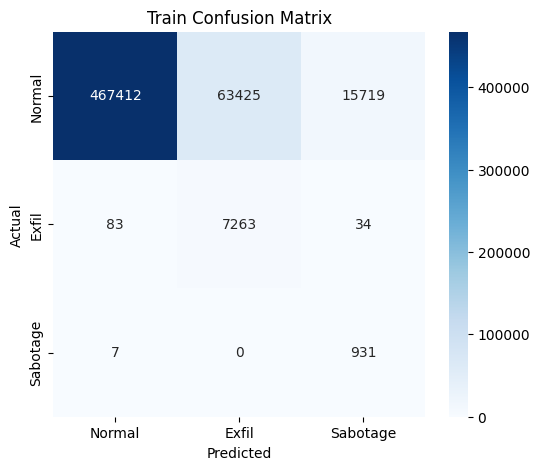

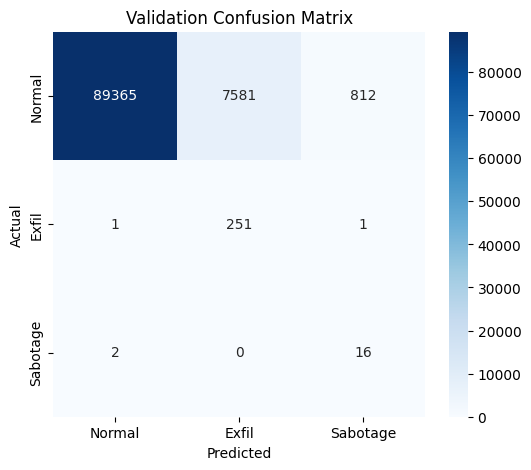

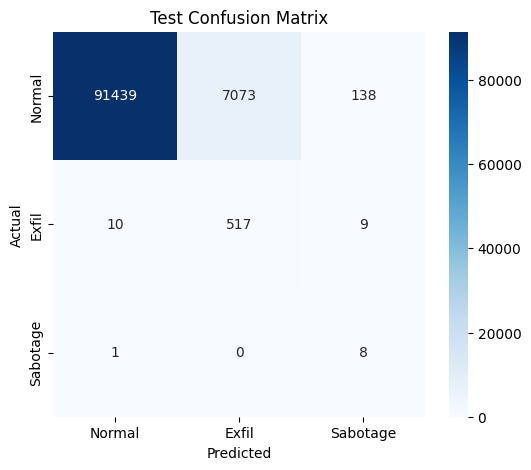

In [141]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# 🔥 LOAD BEST MODEL
# --------------------------------------------------
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)
model.eval()

print("✅ Loaded best_model.pt")


# --------------------------------------------------
# 🔥 PREDICTION FUNCTION (same as training)
# --------------------------------------------------
STEP1_THRESHOLD = 0.375
STEP2_THRESHOLD = 0.275

def get_predictions(s1, s2, t1=STEP1_THRESHOLD, t2=STEP2_THRESHOLD):
    prob = torch.sigmoid(s1).squeeze()
    pred1 = (prob >= t1).long()

    final_pred = torch.zeros_like(pred1)
    threat_idx = (pred1 == 1)

    if threat_idx.sum() > 0:
        s2_prob = torch.softmax(s2[threat_idx], dim=1)
        pred_class = (s2_prob[:, 1] >= t2).long()
        final_pred[threat_idx] = pred_class + 1

    return final_pred


# --------------------------------------------------
# 🔥 EVALUATION FUNCTION
# --------------------------------------------------
def evaluate(loader, name="DATA"):

    all_preds = []
    all_true = []

    with torch.no_grad():
        for X, y1, y2, y_orig in loader:
            X = X.to(device)

            s1, s2, _ = model(X)
            preds = get_predictions(s1, s2)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y_orig.cpu().numpy())

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)

    # Metrics
    acc  = accuracy_score(all_true, all_preds)
    f1m  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    f1w  = f1_score(all_true, all_preds, average='weighted', zero_division=0)

    prec = precision_score(all_true, all_preds,
                           labels=[0,1,2], average=None, zero_division=0)
    rec  = recall_score(all_true, all_preds,
                        labels=[0,1,2], average=None, zero_division=0)
    f1pc = f1_score(all_true, all_preds,
                    labels=[0,1,2], average=None, zero_division=0)

    cm = confusion_matrix(all_true, all_preds, labels=[0,1,2])

    print(f"\n{'='*50}")
    print(f"📊 {name} RESULTS")
    print(f"{'='*50}")

    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {f1m:.4f}")
    print(f"Weighted F1  : {f1w:.4f}")

    print("\nPer-class:")
    print(f"{'Class':<12} {'Prec':>8} {'Recall':>8} {'F1':>8}")
    print("-"*40)

    classes = ["Normal", "Exfil", "Sabotage"]
    for i in range(3):
        print(f"{classes[i]:<12} {prec[i]:>8.4f} {rec[i]:>8.4f} {f1pc[i]:>8.4f}")

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds,
                                target_names=classes, zero_division=0))

    return cm


# --------------------------------------------------
# 🔥 CONFUSION MATRIX PLOT
# --------------------------------------------------
def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["Normal","Exfil","Sabotage"],
                yticklabels=["Normal","Exfil","Sabotage"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


# --------------------------------------------------
# 🔥 RUN EVALUATION
# --------------------------------------------------
cm_train = evaluate(train_loader, "TRAIN")
cm_val   = evaluate(val_loader,   "VALIDATION")
cm_test  = evaluate(test_loader,  "TEST")


# --------------------------------------------------
# 🔥 VISUALIZE
# --------------------------------------------------
plot_cm(cm_train, "Train Confusion Matrix")
plot_cm(cm_val,   "Validation Confusion Matrix")
plot_cm(cm_test,  "Test Confusion Matrix")

In [142]:
import torch
import os

save_dir = "saved_data"
os.makedirs(save_dir, exist_ok=True)

# ---- TRAIN ----
torch.save({
    "X": X_train,
    "y1": y1_train,
    "y2": y2_train,
    "y_orig": y_orig_train
}, f"{save_dir}/train.pt")

# ---- VAL ----
torch.save({
    "X": X_val,
    "y1": y1_val,
    "y2": y2_val,
    "y_orig": y_orig_val
}, f"{save_dir}/val.pt")

# ---- TEST ----
torch.save({
    "X": X_test,
    "y1": y1_test,
    "y2": y2_test,
    "y_orig": y_orig_test
}, f"{save_dir}/test.pt")

print("✅ Data saved successfully!")

✅ Data saved successfully!


COMMNENTS